In [2]:
from dotenv import load_dotenv

load_dotenv()

True

In [3]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [4]:
from langchain_core.messages import AnyMessage
from typing_extensions import TypedDict
from typing import List

# 상태 정의
class State(TypedDict):
    messages: List[AnyMessage | str]

In [5]:
from langchain_core.prompts import PromptTemplate

# 사용자와 대화할 노드(agent): communicator
def communicator(state: State):
    print("\n\n============ COMMUNICATOR ============")

    # 시스템 프롬프트 정의
    communicator_system_prompt = PromptTemplate.from_template(
        """
        너는 책을 쓰는 AI팀의 커뮤니케이터로서, 
        AI팀의 진행상황을 사용자에게 보고하고, 사용자의 의견을 파악하기 위한 대화를 나눈다. 

        messages: {messages}
        """
    )

    #② 시스템 프롬프트와 모델을 연결
    system_chain = communicator_system_prompt | llm

    # 상태에서 메시지를 가져옴
    messages = state["messages"]

    # 입력값 정의
    inputs = {"messages": messages}

    # 스트림되는 메시지를 출력하면서, gathered에 모으기
    gathered = None

    print('\nAI\t: ', end='')
    for chunk in system_chain.stream(inputs):
        print(chunk.content, end='')

        if gathered is None:
            gathered = chunk
        else:
            gathered += chunk

    messages.append(gathered)

    return {"messages": messages}

In [6]:
from langgraph.graph import StateGraph

# 상태 그래프 정의
graph_builder = StateGraph(State)

In [7]:
# Nodes
graph_builder.add_node("communicator", communicator)

In [9]:
from langgraph.graph import START, END

# Edges
graph_builder.add_edge(START, "communicator")
graph_builder.add_edge("communicator", END)

In [10]:
graph = graph_builder.compile()

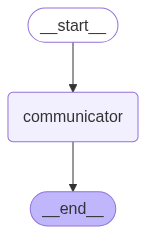

In [14]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [16]:
from langchain_core.messages import SystemMessage
from datetime import datetime

# 상태 초기화
state = State(
    messages = [
        SystemMessage(
                f"""
            너희 AI들은 사용자의 요구에 맞는 책을 쓰는 작가팀이다.
            사용자가 사용하는 언어로 대화하라.

            현재시각은 {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}이다.

            """
        )
    ],
)

In [ ]:
from langchain_core.messages import HumanMessage
import json

while True:
    user_input = input("\nUser\t: ").strip()

    if user_input.lower() in ['exit', 'quit', 'q']:
        print("Goodbye!")
        break
    
    state["messages"].append(HumanMessage(user_input))
    state = graph.invoke(state)

    print('\n------------------------------------ MESSAGE COUNT\t', len(state["messages"]))

    state_dict = {}

    messages = [(m.__class__.__name__, m.content) for m in state["messages"]]

    state_dict["messages"] = messages

    with open("./output/state.json", "w", encoding='utf-8') as f:
        json.dump(state_dict, f, indent=4, ensure_ascii=False)



============ COMMUNICATOR ============

AI	: 

Retrying langchain_google_genai.chat_models._chat_with_retry.<locals>._chat_with_retry in 2.0 seconds as it raised ResourceExhausted: 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. [violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerDayPerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-2.5-flash"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 250
}
, links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, retry_delay {
  seconds: 16
}
].
